In [ ]:
#### filter invalid sample: DeQA(fake) > DeQA(real) ####
import os
import pandas as pd

ext_list = [".png", ".PNG", ".jpg", ".jpeg", ".JPG", ".JPEG"]
real_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/real"
fake_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/fake"

all_information_csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/paired_real_generated_dataset/high_quality_train.csv"
fake_deqa_csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/deqa_fake_score.csv"
real_deqa_csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/deqa_real_score.csv"
output_csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/train_real_fake_gap_0.5.csv"

# Load dataframes
all_information_df = pd.read_csv(all_information_csv_file_path)
fake_deqa_df = pd.read_csv(fake_deqa_csv_file_path)
real_deqa_df = pd.read_csv(real_deqa_csv_file_path)

# Check column names (in case deqa column name varies)
print("fake_deqa_df columns:", fake_deqa_df.columns.tolist())
print("real_deqa_df columns:", real_deqa_df.columns.tolist())
print("all_information_df columns:", all_information_df.columns.tolist())

fake_deqa_col, real_deqa_col = "deqa_score", "deqa_score"

# Step 1: Find common UIDs
common_uid_list = list(set(fake_deqa_df['uid']) & set(real_deqa_df['uid']))
print(f"\nStep 1: Found {len(common_uid_list)} common UIDs")

# Step 2: Filter UIDs where real_deqa > fake_deqa
# Create lookup dictionaries for faster access
fake_deqa_dict = dict(zip(fake_deqa_df['uid'], fake_deqa_df[fake_deqa_col]))
real_deqa_dict = dict(zip(real_deqa_df['uid'], real_deqa_df[real_deqa_col]))

valid_uid_list = []
for uid in common_uid_list:
    real_score = real_deqa_dict[uid]
    fake_score = fake_deqa_dict[uid]
    # if real_score > fake_score: # add_noise-denoise-half
    # if real_score > fake_score and real_score > 3.5:
    if real_score - fake_score > 0.5:
        win_image_path = None
        for ext in ext_list:
            win_image_path = os.path.join(real_image_dir, f"{uid}{ext}")
            if os.path.exists(win_image_path):
                break
        if win_image_path is None:
            print(f"Warning: No valid image found for uid {uid}")
            continue
        
        lose_image_path = None
        for ext in ext_list:
            lose_image_path = os.path.join(fake_image_dir, f"{uid}{ext}")
            if os.path.exists(lose_image_path):
                break
        if lose_image_path is None:
            print(f"Warning: No valid image found for uid {uid}")
        
        prompt = all_information_df.loc[all_information_df['uid'] == uid, 'PROMPT'].values[0]
        
        valid_uid_list.append({
            'uid': uid,
            'prompt': prompt,
            'win_image_path': win_image_path,
            'lose_image_path': lose_image_path
        })

print(f"Step 3: Writing {len(valid_uid_list)} valid samples to {output_csv_file_path}")
pd.DataFrame(valid_uid_list).to_csv(output_csv_file_path, index=False)

In [ ]:
#### Visualize (real image, add noise and denoise image) ####
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import random
import textwrap

specific_uid = "5bc49cc1-767c-403a-8aec-800b69c74e51"
csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/chameleon_real-random_add_noise_step/pickscore_0.02_uids.csv"
df = pd.read_csv(csv_file_path)
row = df[df['uid'] == specific_uid].index[0]

win_image_path = df.iloc[row]['win_image_path']
lose_image_path = df.iloc[row]['lose_image_path']
uid = df.iloc[row]['uid']
prompt = df.iloc[row]['prompt']
win_image = Image.open(win_image_path)
lose_image = Image.open(lose_image_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

axes[0].imshow(lose_image)
axes[0].set_title("Fake (Add noise and denoise)")
axes[0].axis('off') 

axes[1].imshow(win_image)
axes[1].set_title("Real")
axes[1].axis('off')

# 将 prompt 按每行 60 个字符换行
wrapped_prompt = '\n'.join(textwrap.wrap(prompt, width=60))
fig.suptitle(f"UID: {uid}\n{wrapped_prompt}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
#### Visualize (real image, inpainting image, add noise and denoise image) ####
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import random
import textwrap
import os

specific_uid = "0gOu95wg"
csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/paired_real_generated_dataset/high_quality_train.csv"
real_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/real"
inpainting_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/general_1/fake"
add_noise_denoise_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/fake"
df = pd.read_csv(csv_file_path)
row = df[df['uid'] == specific_uid].index[0]

uid = df.iloc[row]['uid']
prompt = df.iloc[row]['PROMPT']

# 查找并加载三张图片
ext_list = [".png", ".PNG", ".jpg", ".jpeg", ".JPG", ".JPEG"]
real_image_path = None
inpainting_image_path = None
add_noise_denoise_image_path = None

for ext in ext_list:
    if real_image_path is None:
        path = os.path.join(real_image_dir, f"{uid}{ext}")
        if os.path.exists(path):
            real_image_path = path
    if inpainting_image_path is None:
        path = os.path.join(inpainting_image_dir, f"{uid}{ext}")
        if os.path.exists(path):
            inpainting_image_path = path
    if add_noise_denoise_image_path is None:
        path = os.path.join(add_noise_denoise_image_dir, f"{uid}{ext}")
        if os.path.exists(path):
            add_noise_denoise_image_path = path

# 加载图片
real_image = Image.open(real_image_path) if real_image_path else None
inpainting_image = Image.open(inpainting_image_path) if inpainting_image_path else None
add_noise_denoise_image = Image.open(add_noise_denoise_image_path) if add_noise_denoise_image_path else None

fig, axes = plt.subplots(1, 3, figsize=(15, 6), dpi=300)

axes[0].imshow(real_image)
axes[0].set_title("Real", fontsize=12)
axes[0].axis('off') 

axes[1].imshow(inpainting_image)
axes[1].set_title("Inpainting", fontsize=12)
axes[1].axis('off')

axes[2].imshow(add_noise_denoise_image)
axes[2].set_title("Add noise Denoise", fontsize=12)
axes[2].axis('off')

# 将 prompt 按每行 60 个字符换行
wrapped_prompt = '\n'.join(textwrap.wrap(prompt, width=120))
fig.suptitle(f"UID: {uid}\n{wrapped_prompt}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
#### Filter Sample v2 ####
import pandas as pd
import os

base_reward_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step"
reward_model_list = [ "deqa", "imagereward" ]

# Store valid UIDs for each reward model
valid_uids_per_model = {}

print("=" * 60)
print("Filtering UIDs where real_image_score > fake_image_score")
print("=" * 60)

for reward_model in reward_model_list:
    # Read score file (each model has its own subdirectory)
    score_file = os.path.join(base_reward_dir, reward_model, f"{reward_model}_score.csv")
    
    if not os.path.exists(score_file):
        print(f"Warning: {score_file} not found, skipping...")
        continue
    
    print(f"\n[{reward_model}]")
    print(f"  Reading: {score_file}")
    df = pd.read_csv(score_file)
    
    print(f"  Total samples: {len(df)}")
    
    # Filter UIDs where real_image_score > fake_image_score
    valid_df = df[df['real_image_score'] > df['fake_image_score']]
    
    print(f"  Valid samples (real > fake): {len(valid_df)}")
    print(f"  Percentage: {len(valid_df) / len(df) * 100:.2f}%")
    
    # Store valid UIDs
    valid_uids_per_model[reward_model] = set(valid_df['uid'].tolist())

# Find intersection: UIDs that satisfy the condition in ALL reward models
if len(valid_uids_per_model) > 0:
    # Start with the first available model's valid UIDs
    first_model = list(valid_uids_per_model.keys())[0]
    common_valid_uids = valid_uids_per_model[first_model]
    
    # Find intersection with all other models
    for reward_model in valid_uids_per_model.keys():
        if reward_model != first_model:
            common_valid_uids = common_valid_uids & valid_uids_per_model[reward_model]
    
    print("\n" + "=" * 60)
    print("Final Results (UIDs valid in ALL reward models):")
    print("=" * 60)
    print(f"Total valid UIDs: {len(common_valid_uids)}")
    
    # Show statistics for each model
    for reward_model in reward_model_list:
        if reward_model in valid_uids_per_model:
            overlap = len(common_valid_uids & valid_uids_per_model[reward_model])
            total = len(valid_uids_per_model[reward_model])
            print(f"  {reward_model}: {overlap} / {total} ({overlap/total*100:.2f}%)")
    
    # Convert to sorted list
    common_valid_uids_list = sorted(list(common_valid_uids))
    
else:
    print("No valid data found!")


### Get specific information from csv file ###
ext_list = [".png", ".PNG", ".jpg", ".jpeg", ".JPG", ".JPEG"]
real_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/real"
fake_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/fake"
all_information_csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/paired_real_generated_dataset/high_quality_train.csv"
all_information_df = pd.read_csv(all_information_csv_file_path)
specific_information_list = []
output_csv_file_path = f"/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/imagereward_deqa_valid_uids.csv"
for uid in common_valid_uids_list:
    for ext in ext_list:
        real_image_path = os.path.join(real_image_dir, f"{uid}{ext}")
        if os.path.exists(real_image_path):
            break
    for ext in ext_list:
        fake_image_path = os.path.join(fake_image_dir, f"{uid}{ext}")
        if os.path.exists(fake_image_path):
            break
    
    row = all_information_df[all_information_df['uid'] == uid].iloc[0]
    prompt = row['PROMPT']
    specific_information_list.append({
        'uid': uid,
        'prompt': prompt,
        'win_image_path': real_image_path,
        'lose_image_path': fake_image_path
    })

pd.DataFrame(specific_information_list).to_csv(output_csv_file_path, index=False)

In [ ]:
#### Check Dinov max difference ####
import os
import pandas as pd
import matplotlib.pyplot as plt

# max_diff_path = "/data3/chenweiyan/notebook/fine-tune-diffusion/spo_gitee/notebook/sd_1.5-add_noise-denoise/lpips_alex_diff.csv"
# max_diff_df = pd.read_csv(max_diff_path)
# diff_col = "lpips_diff"
# max_diff_stats = max_diff_df[diff_col].agg(['mean', 'std', 'max', 'min'])
# print(max_diff_stats)

# plt.figure(figsize=(8, 6),dpi=300)
# plt.hist(max_diff_df[diff_col], bins=30, edgecolor='black', alpha=0.7)
# plt.title(f'Distribution of {diff_col}', fontsize=16)
# plt.xlabel(diff_col, fontsize=14)
# plt.ylabel('Frequency', fontsize=14)
# plt.grid(True)
# plt.show()


base_reward_score_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step"
reward_model_list = [ "deqa", "imagereward", "pickscore" ]
score_df_dict = { reward_model: pd.read_csv(os.path.join(base_reward_score_dir, reward_model, f"{reward_model}_score.csv")) for reward_model in reward_model_list }
real_image_win_list = { reward_model: 0 for reward_model in reward_model_list }    

uid_list = []
for idx, row in score_df_dict["pickscore"].iterrows():
    if row["real_image_score"] - row["fake_image_score"] > 0.02:
        uid_list.append(row["uid"])

for uid in uid_list:
    for reward_model in reward_model_list:
        row = score_df_dict[reward_model][score_df_dict[reward_model]['uid'] == uid]
        if row['real_image_score'].values[0] > row['fake_image_score'].values[0]:
            real_image_win_list[reward_model] += 1

total_uid_num = len(uid_list)
for reward_model in reward_model_list:
    print(f"{reward_model}: {real_image_win_list[reward_model]} / {total_uid_num} ({real_image_win_list[reward_model] / total_uid_num * 100:.2f}%)")


In [3]:
#### Link win image and lose image ####
import os
import pandas as pd

csv_file_name = "pickscore_0.02_uids"
base_target_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/visualization/chameleon_real"
base_csv_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/chameleon_real"

ext_list = [".png", ".PNG", ".jpg", ".jpeg", ".JPG", ".JPEG"]
df = pd.read_csv(os.path.join(base_csv_dir, f"{csv_file_name}.csv"))
target_image_dir = os.path.join(base_target_image_dir, csv_file_name)
os.makedirs(os.path.join(target_image_dir, "real"), exist_ok=True)
os.makedirs(os.path.join(target_image_dir, "fake"), exist_ok=True)

for index, row in df.iterrows():
    uid = row['uid']
    source_win_image_path = row['win_image_path']
    source_lose_image_path = row['lose_image_path']

    win_image_name = os.path.basename(source_win_image_path)
    lose_image_name = os.path.basename(source_lose_image_path)

    target_win_image_path = os.path.join(target_image_dir, "real", win_image_name)
    target_lose_image_path = os.path.join(target_image_dir, "fake", lose_image_name)

    os.symlink(source_win_image_path, target_win_image_path)
    os.symlink(source_lose_image_path, target_lose_image_path)


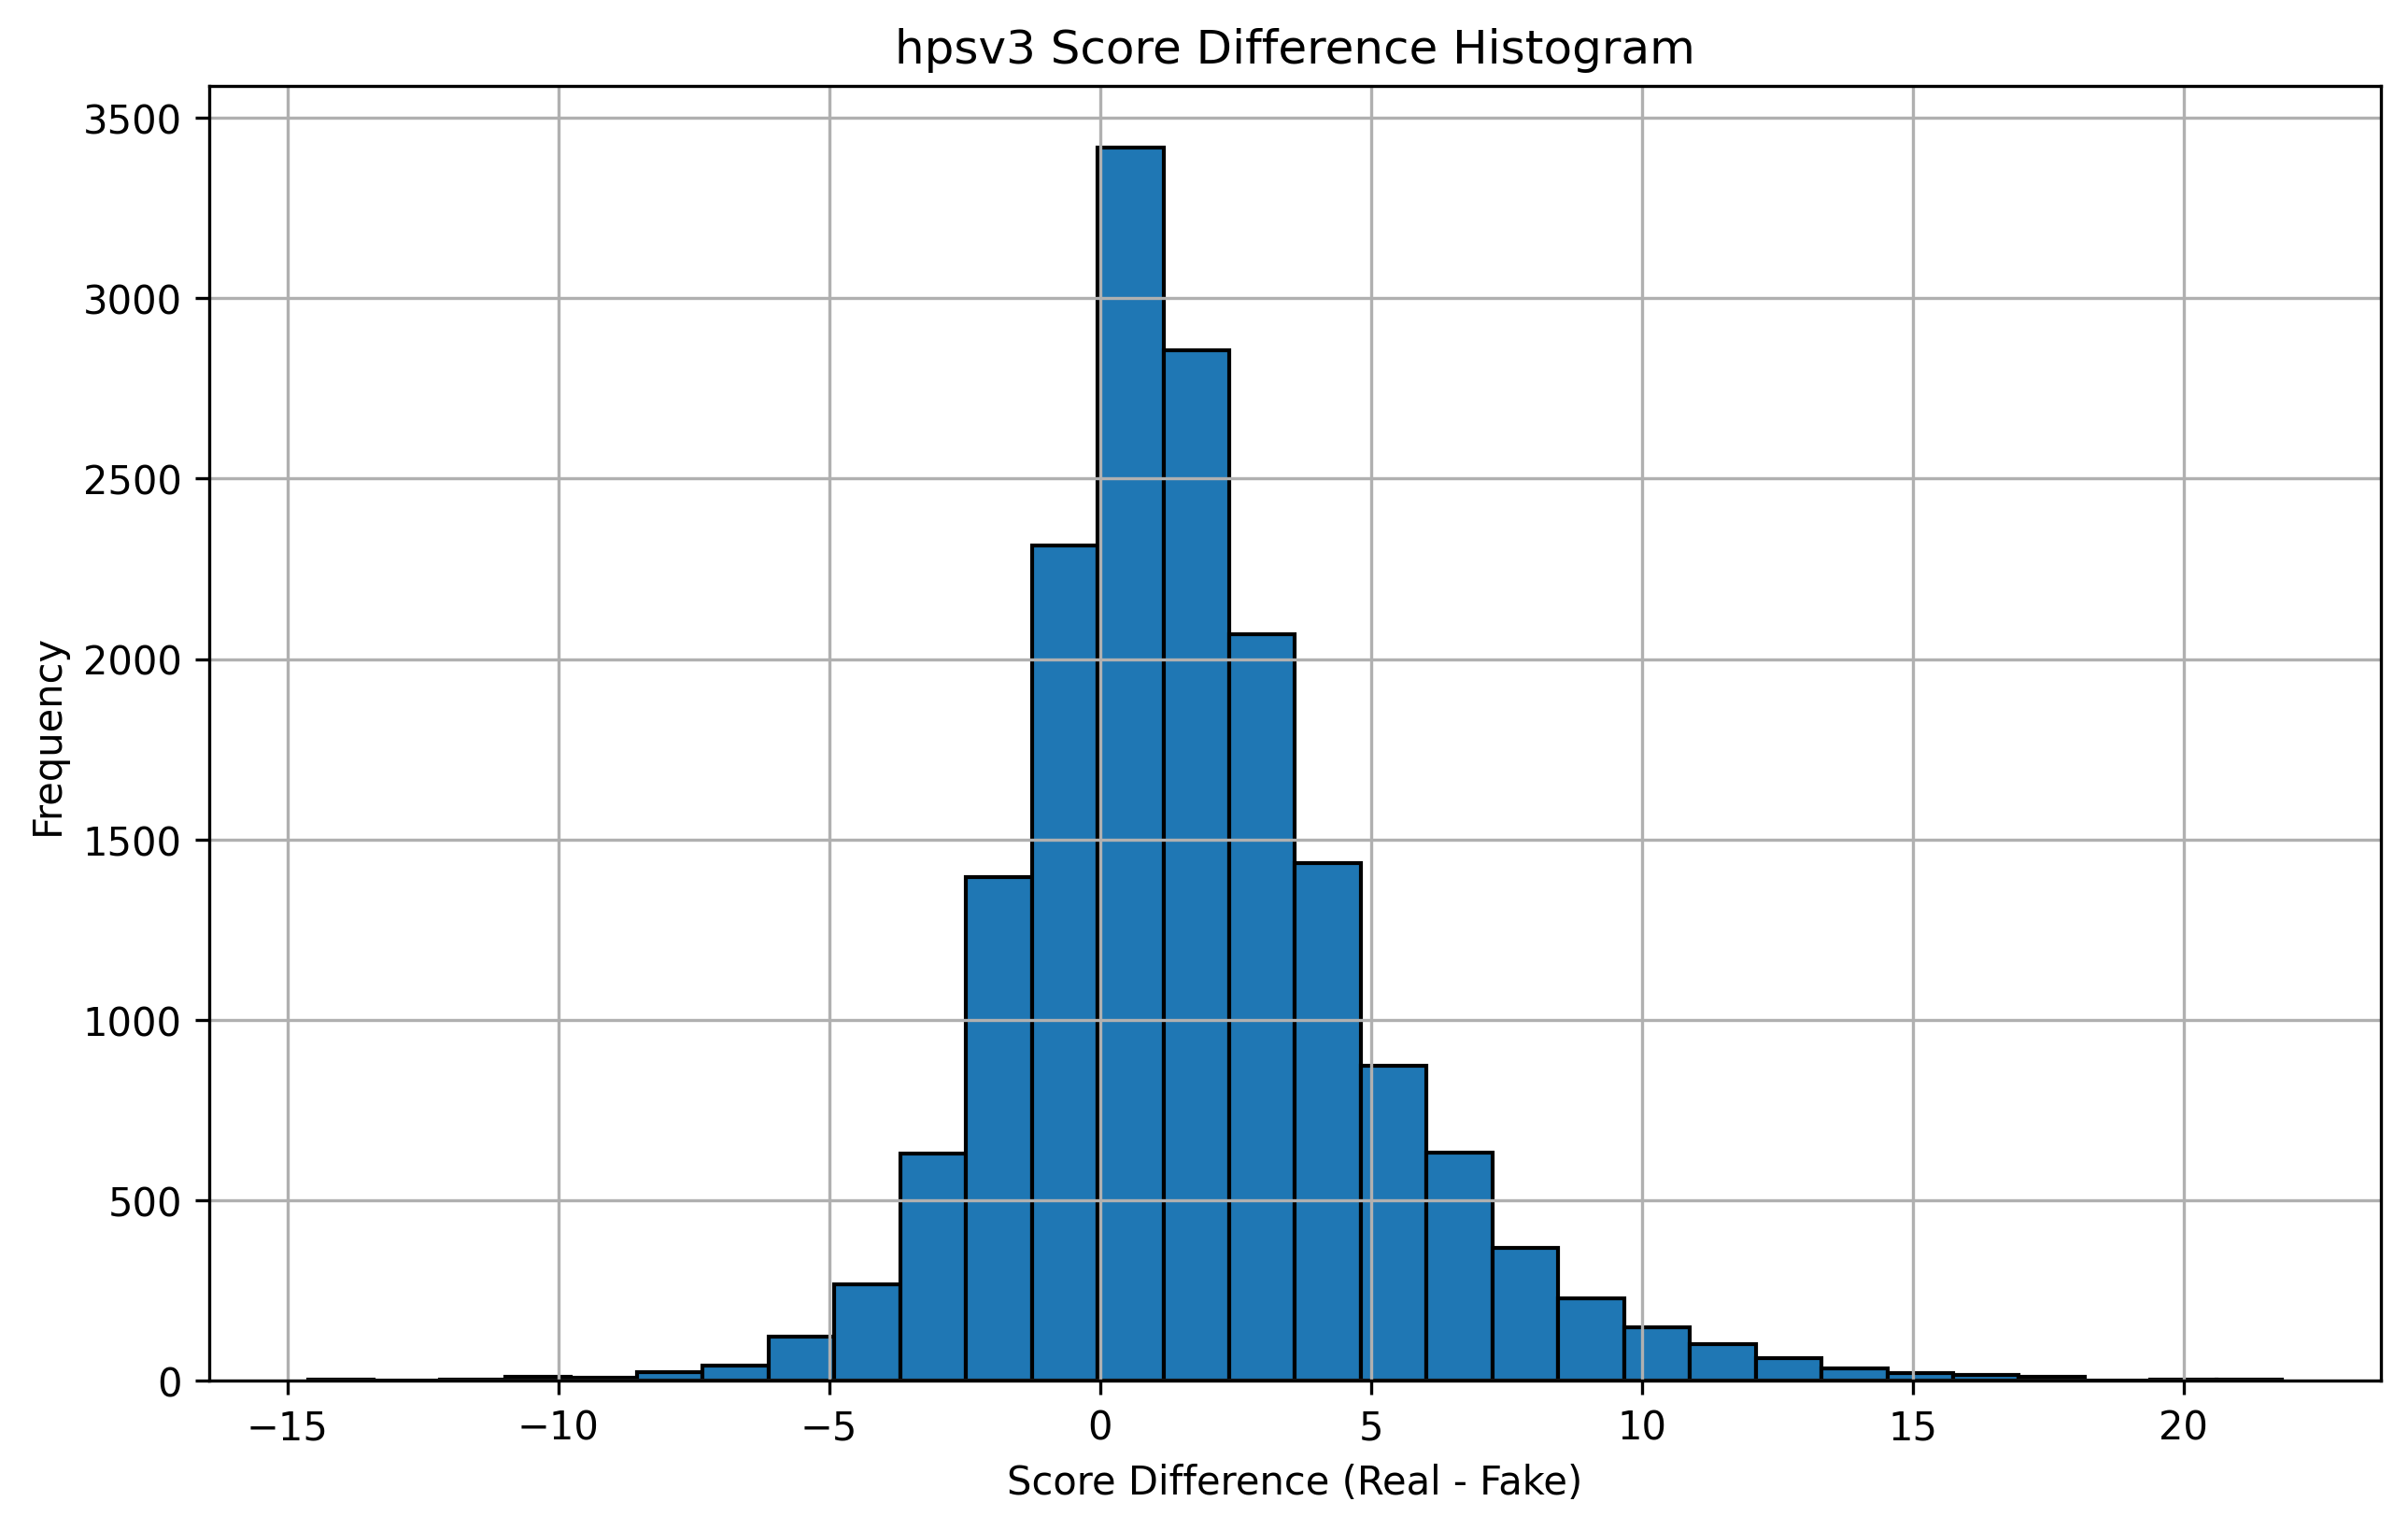

Positive difference count: 4860


In [7]:
#### Analysis PickScore Diff ####
import os
import pandas as pd
import matplotlib.pyplot as plt

reward_model = "hpsv3"
base_reward_score_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/general_1"
score_df = pd.read_csv(os.path.join(base_reward_score_dir, reward_model, f"{reward_model}_score.csv"))

score_diff_list = []
for idx, row in score_df.iterrows():
    uid = row["uid"]
    real_score = row["real_image_score"]
    fake_score = row["fake_image_score"]
    score_diff_list.append(real_score - fake_score)

plt.figure(figsize=(10, 6), dpi=300)
plt.hist(score_diff_list, bins=30, edgecolor='black')  
plt.title(f"{reward_model} Score Difference Histogram")
plt.xlabel("Score Difference (Real - Fake)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

positive_diff_count = sum(x > 3 for x in score_diff_list)
print(f"Positive difference count: {positive_diff_count}")

In [ ]:
#### Analysis PickScore Average ####
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

reward_model = "pickscore"
base_reward_score_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/general_1"
score_df = pd.read_csv(os.path.join(base_reward_score_dir, reward_model, f"{reward_model}_score.csv"))

real_score_list = []
fake_score_list = []
score_diff_list = []
for idx, row in score_df.iterrows():
    uid = row["uid"]
    real_score = row["real_image_score"]
    fake_score = row["fake_image_score"]
    real_score_list.append(real_score)
    fake_score_list.append(fake_score)
    score_diff_list.append(real_score - fake_score)

real_mean = np.mean(real_score_list)
real_var = np.var(real_score_list)
real_max = np.max(real_score_list)
real_min = np.min(real_score_list)
fake_mean = np.mean(fake_score_list)
fake_var = np.var(fake_score_list)
fake_max = np.max(fake_score_list)
fake_min = np.min(fake_score_list)

print("Real Score")
print(f"mean: {real_mean:.4f}, var: {real_var:.4f}, max: {real_max:.4f}, min: {real_min:.4f}")
print("Fake Score")
print(f"mean: {fake_mean:.4f}, var: {fake_var:.4f}, max: {fake_max:.4f}, min: {fake_min:.4f}")

In [ ]:
#### Get Pickscore (gap > 0.02) uid ####
import os
import pandas as pd
import matplotlib.pyplot as plt

all_information_csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/paired_real_generated_dataset/high_quality_train.csv"
all_information_df = pd.read_csv(all_information_csv_file_path)
ext_list = [".png", ".PNG", ".jpg", ".jpeg", ".JPG", ".JPEG"]
real_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/general_1/real"
fake_image_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/general_1/fake"

reward_model = "hpsv3"
base_reward_score_dir = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/general_1"
score_df = pd.read_csv(os.path.join(base_reward_score_dir, reward_model, f"{reward_model}_score.csv"), dtype={"uid": str})
# target_csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/u2net_next_inpainting/chameleon_real/pickscore_0.02_uids.csv"
mean_real_pickscore = score_df["real_image_score"].mean()
pickscore_gap_information_list = []
for index, row in score_df.iterrows():
    uid = row["uid"]
    if row["real_image_score"] - row["fake_image_score"] > 0.02:
        win_image_path, lose_image_path = None, None
        
        for ext in ext_list:
            win_image_path = os.path.join(real_image_dir, f"{uid}{ext}")
            if os.path.exists(win_image_path):
                break
        if win_image_path is None:
            print(f"Warning: No valid image found for uid {uid}")
            continue
        
        for ext in ext_list:
            lose_image_path = os.path.join(fake_image_dir, f"{uid}{ext}")
            if os.path.exists(lose_image_path):
                break
        if lose_image_path is None:
            print(f"Warning: No valid image found for uid {uid}")
            continue
        
        prompt = all_information_df.loc[all_information_df['uid'] == uid, 'prompt'].values[0]
        pickscore_gap_information_list.append({
            'uid': uid,
            'prompt': prompt,
            'win_image_path': win_image_path,
            'lose_image_path': lose_image_path
        })

print(f"pickscore_gap_information_list: {len(pickscore_gap_information_list)}")
pd.DataFrame(pickscore_gap_information_list).to_csv(target_csv_file_path, index=False)


In [ ]:
#### Combine two csv file ####
import os
import pandas as pd

csv_file_path_1 = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/pickscore_0.02_uids.csv"
csv_file_path_2 = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/qwen_3_caption-general_append/pickscore_0.02_uids.csv"

to_csv_file_path = "/data_center/data2/dataset/chenwy/21164-data/dpo_dataset/add_noise_denoise/random_add_noise_step/pickscore_0.02_uids-general_all.csv"

# Read both CSV files
df1 = pd.read_csv(csv_file_path_1)
df2 = pd.read_csv(csv_file_path_2)

print(f"CSV file 1: {len(df1)} rows")
print(f"CSV file 2: {len(df2)} rows")

# Combine the two dataframes
combined_df = pd.concat([df1, df2], ignore_index=True)

# Remove duplicates based on uid (if any)
combined_df = combined_df.drop_duplicates(subset=['uid'], keep='first')

print(f"Combined: {len(combined_df)} rows (after removing duplicates)")

# Save to target CSV file
combined_df.to_csv(to_csv_file_path, index=False)
print(f"Saved to: {to_csv_file_path}")